# Double Integrator Hand-Crafted CBF Test

Tests the CBF-QP code (`min_norm_cbf`, `gcbf_qp`) with an analytically-valid hand-crafted barrier
function for the double integrator, bypassing the learned network entirely.

**System:** $\dot{p} = v$, $\dot{v} = u_{\max} \cdot u$, $u \in [-1, 1]$, walls at $p = \pm 1$.

**CBF (HOCBF formulation):** The linear constraints $h_{\mathrm{ub}}(x) = p - 1$ and $h_{\mathrm{lb}}(x) = -(p+1)$
have relative degree 2 ($L_G h = 0$), so we use the HOCBF barriers:
$$B_{\mathrm{ub}}(x) = v + \alpha_{\mathrm{hocbf}} \cdot h_{\mathrm{ub}}(x), \quad B_{\mathrm{lb}}(x) = -v + \alpha_{\mathrm{hocbf}} \cdot h_{\mathrm{lb}}(x)$$
These have $L_G B = \pm u_{\max}$ (constant), giving direct control authority.

**Sign convention:** $V(x) < 0$ is **safe**.

**Performance note:** Rollouts use `jax.lax.scan` so they can be `jit`-compiled end-to-end.

In [111]:
import functools as ft
import sys
sys.path.insert(0, '../../src')

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from mrncbf.utils.jax_utils import jax_default_x32
from mrncbf.qp.min_norm_cbf import min_norm_cbf, gcbf_qp

jax_default_x32()

# ── System parameters ─────────────────────────────────────────────────────────
UMAX        = 1.0
PWALL       = 1.0
u_lb        = jnp.array([-1.0])
u_ub        = jnp.array([ 1.0])

ALPHA_HOCBF = 5.0    # HOCBF composition gain
ALPHA_QP    = 1.0    # CBF-QP decay rate

DT = 0.05
T  = 200

## System dynamics and hand-crafted CBF

In [112]:
def f(x):
    p, v = x
    return jnp.array([v, 0.0])

def G(x):
    return jnp.array([[0.0], [UMAX]])

def h_raw(x):
    """Geometric constraints — relative-degree 2, NOT a valid CBF directly."""
    p, v = x
    return jnp.array([-(p + PWALL),   # safe: p > -1
                        p - PWALL])    # safe: p <  1

def B_hocbf(x, alpha=ALPHA_HOCBF):
    """
    HOCBF barriers — valid relative-degree-1 CBFs (B < 0 is safe).

      B_lb = -v + alpha*(-(p+1))    dB_lb/dx = [-alpha, -1]  =>  LG B_lb = -UMAX
      B_ub =  v + alpha*(p-1)       dB_ub/dx = [ alpha,  1]  =>  LG B_ub = +UMAX
    """
    h = h_raw(x)
    p, v = x
    return jnp.array([-v + alpha * h[0],
                        v + alpha * h[1]])

# ── Verify gradients ──────────────────────────────────────────────────────────
x_test  = jnp.array([0.8, 0.5])
Bx_auto = jax.jacobian(B_hocbf)(x_test)
Bx_anal = jnp.array([[-ALPHA_HOCBF, -1.0],
                      [ ALPHA_HOCBF,  1.0]])
LG_B    = Bx_auto @ G(x_test)    # should be [[-UMAX], [UMAX]]

print(f"Max gradient error  = {jnp.max(jnp.abs(Bx_auto - Bx_anal)):.2e}")
print(f"LG B (should be [[-{UMAX}], [{UMAX}]]) = {LG_B.ravel()}")

Max gradient error  = 0.00e+00
LG B (should be [[-1.0], [1.0]]) = [-1.  1.]


## Policies

In [113]:
def nom_pol(x):
    p, v = x
    kp, kd = 2.0, 0.2
    return jnp.clip(jnp.array([-kp * p - kd * v]), u_lb, u_ub)

def cbf_pol(x, alpha=ALPHA_QP):
    h_V   = B_hocbf(x)
    hx_Vx = jax.jacobian(B_hocbf)(x)
    u_opt, r, _ = min_norm_cbf(alpha, u_lb, u_ub, h_V, hx_Vx, f(x), G(x), nom_pol(x))
    return u_opt

def _gcbf_ingredients(x, alpha=ALPHA_HOCBF):
    """Returns (h_V, h_Lf_V, h_LG_V) — pure JAX, vmappable."""
    hx_Vx = jax.jacobian(ft.partial(B_hocbf, alpha=alpha))(x)  # (nh, nx)
    h_V   = B_hocbf(x, alpha=alpha)                             # (nh,)
    h_Lf_V = hx_Vx @ f(x)                                      # (nh,)
    h_LG_V = hx_Vx @ G(x)                                      # (nh, nu)
    return h_V, h_Lf_V, h_LG_V

def gcbf_pol(x, rng_key, epsilon=0.1, n_samples=200, alpha_qp=ALPHA_QP):
    """
    G-CBF: worst-case CBF-QP over a box uncertainty ball.

    Uses jax.random (not np.random) so this function is jit-able.
    """
    samples = x[None] + jax.random.uniform(
        rng_key, shape=(n_samples, x.shape[0]), minval=-epsilon, maxval=epsilon
    )
    h_V_s, h_LfV_s, h_LGV_s = jax.vmap(_gcbf_ingredients)(samples)  # (N,nh), (N,nh), (N,nh,nu)

    nh = h_V_s.shape[1]
    ci = jnp.arange(nh)

    wc_hV  = jnp.argmax(h_V_s, axis=0)                              # (nh,)
    wc_LfV = jnp.argmax(h_LfV_s, axis=0)                            # (nh,)
    wc_LGV = jnp.argmin(jnp.linalg.norm(h_LGV_s, axis=-1), axis=0) # (nh,)

    h_V_wc  = h_V_s [wc_hV,  ci]        # (nh,)
    h_Lf_wc = h_LfV_s[wc_LfV, ci]      # (nh,)
    h_LG_wc = h_LGV_s[wc_LGV, ci, :]   # (nh, nu)

    u_opt, r, _ = gcbf_qp(alpha_qp, u_lb, u_ub,
                           h_V_wc, h_Lf_wc, h_LG_wc,
                           nom_pol(x), relax_eps2=0.1)
    return u_opt, r, h_V_wc, h_Lf_wc, h_LG_wc

## JIT-compiled rollout via `jax.lax.scan`

A plain Python `for` loop either unrolls at trace time (slow compile, huge graph) or outright
fails under `jit`. `lax.scan` threads state through as a carry and compiles a single step body,
giving a ~100× speed-up for long rollouts.

In [114]:
def make_rollout(policy_fn, T=T, dt=DT):
    """
    Returns a jit-compiled rollout function.

    policy_fn must be a pure JAX function: (x,) -> u  (no Python side effects).
    """
    @jax.jit
    def rollout(x0):
        def step(x, _):
            u      = policy_fn(x)
            x_next = x + dt * (f(x) + G(x) @ u)
            return x_next, x           # carry, stacked output
        _, xs = jax.lax.scan(step, x0, None, length=T)
        # xs shape: (T, nx) — excludes x0; prepend it
        return jnp.concatenate([x0[None], xs], axis=0)  # (T+1, nx)
    return rollout


def make_gcbf_rollout(epsilon=0.1, n_samples=200, T=T, dt=DT,
                      base_key=jax.random.PRNGKey(0)):
    """
    G-CBF rollout.  Each step gets its own key via fold_in so samples vary
    across time, but the rollout is still deterministic and jit-able.
    """
    @jax.jit
    def rollout(x0):
        def step(x, step_idx):
            key   = jax.random.fold_in(base_key, step_idx)
            u, _, _, _, _ = gcbf_pol(x, key, epsilon=epsilon, n_samples=n_samples)
            x_next = x + dt * (f(x) + G(x) @ u)
            return x_next, x
        _, xs = jax.lax.scan(step, x0, jnp.arange(T))
        return jnp.concatenate([x0[None], xs], axis=0)
    return rollout


rollout_nom  = make_rollout(nom_pol)
rollout_cbf  = make_rollout(cbf_pol)
rollout_gcbf = make_gcbf_rollout(epsilon=0.3)

# Warm-up compile (first call is slow; subsequent calls are fast)
print("Compiling rollouts (first call)...")
x_dummy = jnp.array([0.5, 0.5])
_ = rollout_nom(x_dummy)
_ = rollout_cbf(x_dummy)
_ = rollout_gcbf(x_dummy)
print("Done.")

Compiling rollouts (first call)...
Done.


## Timing comparison

In [115]:
import time

x0_time = jnp.array([0.8, 1.5])
N_REPS  = 20

def time_fn(fn, x0, reps):
    fn(x0).block_until_ready()  # ensure compiled
    t0 = time.perf_counter()
    for _ in range(reps):
        fn(x0).block_until_ready()
    return (time.perf_counter() - t0) / reps * 1e3  # ms

print(f"Rollout length: T={T} steps")
print(f"nom  rollout: {time_fn(rollout_nom,  x0_time, N_REPS):.2f} ms/rollout")
print(f"cbf  rollout: {time_fn(rollout_cbf,  x0_time, N_REPS):.2f} ms/rollout")
print(f"gcbf rollout: {time_fn(rollout_gcbf, x0_time, N_REPS):.2f} ms/rollout")

Rollout length: T=200 steps
nom  rollout: 1.65 ms/rollout
cbf  rollout: 203.27 ms/rollout
gcbf rollout: 98.61 ms/rollout


## Single-state CBF constraint check

In [116]:
print("CBF constraint check: Lf_B + LG_B*u + alpha*B  (should be <= 0)")
print("=" * 65)

test_states = [
    jnp.array([ 0.8,  1.5]),
    jnp.array([-0.8, -1.5]),
    jnp.array([ 0.0,  0.5]),
    jnp.array([ 0.95, 0.1]),
]

for x0 in test_states:
    B     = B_hocbf(x0)
    Bx    = jax.jacobian(B_hocbf)(x0)
    u_opt = cbf_pol(x0)
    lhs   = Bx @ f(x0) + (Bx @ G(x0) @ u_opt).ravel() + ALPHA_QP * B
    print(f"  x={np.array(x0)}, B={np.array(B).round(3)}, "
          f"u_opt={float(u_opt[0]):.3f}, lhs={np.array(lhs).round(4)}")

CBF constraint check: Lf_B + LG_B*u + alpha*B  (should be <= 0)
  x=[0.8 1.5], B=[-10.5   0.5], u_opt=-1.001, lhs=[-16.9994   6.9994]
  x=[-0.8 -1.5], B=[  0.5 -10.5], u_opt=1.001, lhs=[  6.9994 -16.9994]
  x=[0.  0.5], B=[-5.5 -4.5], u_opt=-0.100, lhs=[-7.9 -2.1]
  x=[0.95 0.1 ], B=[-9.85 -0.15], u_opt=-1.000, lhs=[-9.3502 -0.6498]


## Batch rollouts and phase portrait

Violations — nom: 8, cbf: 4, gcbf: 4


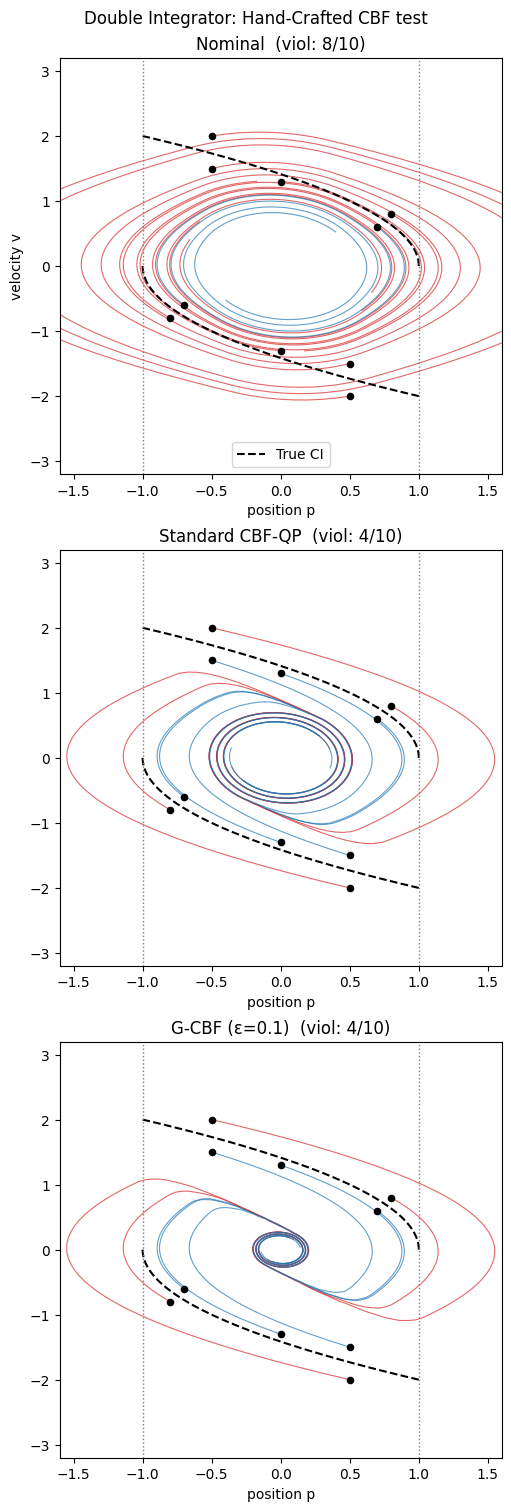

In [ ]:
m


# Batch rollout via vmap
trajs_nom  = jax.vmap(rollout_nom)(x0s)    # (B, T+1, nx)
trajs_cbf  = jax.vmap(rollout_cbf)(x0s)
trajs_gcbf = jax.vmap(rollout_gcbf)(x0s)

def count_violations(trajs):
    """Count trajectories where |p| > PWALL at any step."""
    return int(jnp.sum(jnp.any(jnp.abs(trajs[:, :, 0]) > PWALL + 1e-3, axis=1)))

print(f"Violations — nom: {count_violations(trajs_nom)}, "
      f"cbf: {count_violations(trajs_cbf)}, "
      f"gcbf: {count_violations(trajs_gcbf)}")

# CI boundary
vs_pos = np.linspace(0, 2.0, 100)
vs_neg = np.linspace(-2.0, 0, 100)
ci_p_right = PWALL - vs_pos**2 / (2 * UMAX)
ci_p_left  = vs_neg**2 / (2 * UMAX) - PWALL

fig, axes = plt.subplots(3, 1, figsize=(5, 15), sharey=True, layout="constrained")
all_trajs = [(trajs_nom, "Nominal"), (trajs_cbf, "Standard CBF-QP"), (trajs_gcbf, "G-CBF (ε=0.1)")]

for ax, (trajs, title) in zip(axes, all_trajs):
    n_v = count_violations(trajs)
    for traj in np.array(trajs):
        violated = np.any(np.abs(traj[:, 0]) > PWALL + 1e-3)
        ax.plot(traj[:, 0], traj[:, 1], color="C3" if violated else "C0",
                lw=0.8, alpha=0.7)
        ax.scatter(traj[0, 0], traj[0, 1], s=20, color="k", zorder=5)
    ax.plot(ci_p_right, vs_pos, 'k--', lw=1.5, label='True CI')
    ax.plot(ci_p_left,  vs_neg, 'k--', lw=1.5)
    for xw in [-PWALL, PWALL]:
        ax.axvline(xw, color='gray', lw=1.0, ls=':')
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-3.2, 3.2)
    ax.set_xlabel("position p")
    ax.set_title(f"{title}  (viol: {n_v}/{len(x0s)})")

axes[0].set_ylabel("velocity v")
axes[0].legend()
plt.suptitle("Double Integrator: Hand-Crafted CBF test")
plt.show()

## Per-step constraint check along a single trajectory

For each timestep, verify `Lf_B + LG_B*u + α*B ≤ 0`.
Any positive value (beyond QP solver tolerance) indicates a bug in the QP assembly.

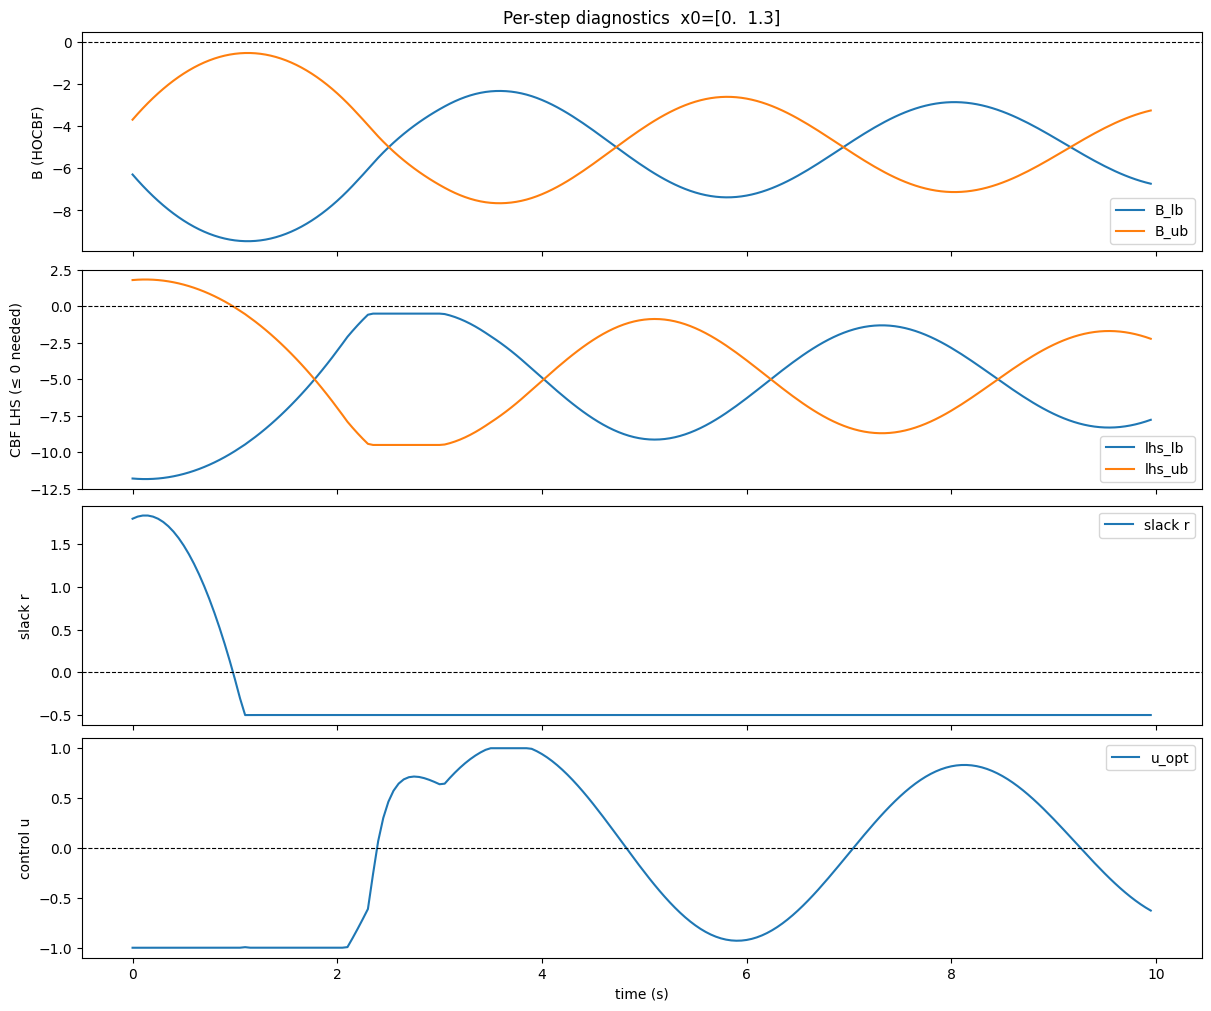

Steps where QP lhs > 1e-4: 20/200
  → 0 means QP constraint is satisfied at every step


In [118]:
# Re-run one trajectory while recording per-step CBF diagnostics
x0_diag = jnp.array([0.0, 1.3])

@jax.jit
def cbf_step_diag(x):
    B     = B_hocbf(x)
    Bx    = jax.jacobian(B_hocbf)(x)
    u_opt, r, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, B, Bx, f(x), G(x), nom_pol(x))
    lhs   = Bx @ f(x) + (Bx @ G(x) @ u_opt).ravel() + ALPHA_QP * B
    x_next = x + DT * (f(x) + G(x) @ u_opt)
    return x_next, (B, lhs, r, u_opt)

_, (B_hist, lhs_hist, r_hist, u_hist) = jax.lax.scan(
    lambda x, _: cbf_step_diag(x), x0_diag, None, length=T
)
ts = jnp.arange(T) * DT

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True, layout="constrained")

axes[0].plot(ts, B_hist[:, 0], label='B_lb')
axes[0].plot(ts, B_hist[:, 1], label='B_ub')
axes[0].axhline(0, color='k', lw=0.8, ls='--')
axes[0].set_ylabel('B (HOCBF)')
axes[0].legend()
axes[0].set_title(f'Per-step diagnostics  x0={np.array(x0_diag)}')

axes[1].plot(ts, lhs_hist[:, 0], label='lhs_lb')
axes[1].plot(ts, lhs_hist[:, 1], label='lhs_ub')
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_ylabel('CBF LHS (≤ 0 needed)')
axes[1].legend()

axes[2].plot(ts, r_hist, label='slack r')
axes[2].axhline(0, color='k', lw=0.8, ls='--')
axes[2].set_ylabel('slack r')
axes[2].legend()

axes[3].plot(ts, u_hist, label='u_opt')
axes[3].axhline(0, color='k', lw=0.8, ls='--')
axes[3].set_ylabel('control u')
axes[3].set_xlabel('time (s)')
axes[3].legend()

plt.show()

n_viol = int(jnp.sum(jnp.any(lhs_hist > 1e-4, axis=-1)))
print(f"Steps where QP lhs > 1e-4: {n_viol}/{T}")
print("  → 0 means QP constraint is satisfied at every step")

## G-CBF per-step constraint check

Same diagnostic for `gcbf_qp`: verify the QP satisfies the worst-case constraint it was given.

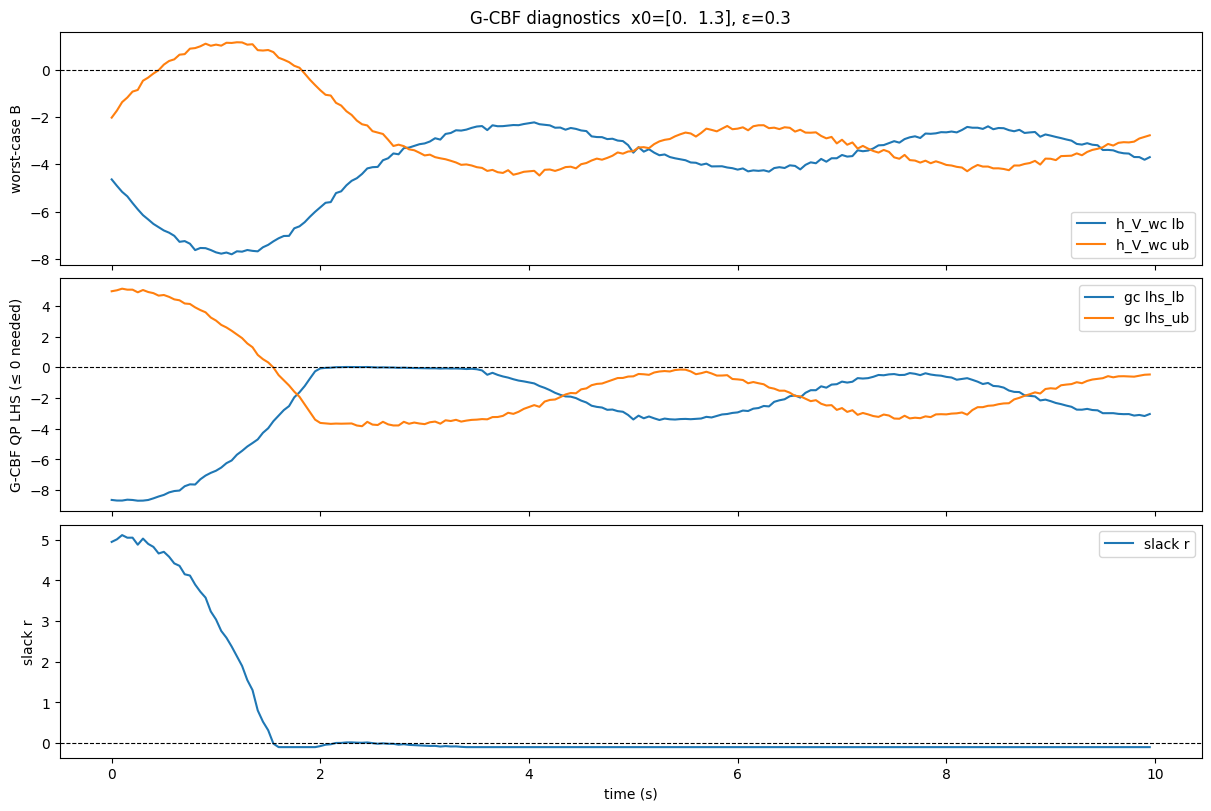

G-CBF: steps where QP lhs > 1e-4: 38/200


In [119]:
BASE_KEY = jax.random.PRNGKey(0)
EPSILON  = 0.3

@jax.jit
def gcbf_step_diag(x, step_idx):
    key   = jax.random.fold_in(BASE_KEY, step_idx)
    u_opt, r, h_V_wc, h_Lf_wc, h_LG_wc = gcbf_pol(x, key, epsilon=EPSILON)
    lhs   = h_Lf_wc + (h_LG_wc @ u_opt).ravel() + ALPHA_QP * h_V_wc
    x_next = x + DT * (f(x) + G(x) @ u_opt)
    return x_next, (h_V_wc, lhs, r)

_, (gc_B_hist, gc_lhs_hist, gc_r_hist) = jax.lax.scan(
    gcbf_step_diag, x0_diag, jnp.arange(T)
)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, layout="constrained")

axes[0].plot(ts, gc_B_hist[:, 0], label='h_V_wc lb')
axes[0].plot(ts, gc_B_hist[:, 1], label='h_V_wc ub')
axes[0].axhline(0, color='k', lw=0.8, ls='--')
axes[0].set_ylabel('worst-case B')
axes[0].legend()
axes[0].set_title(f'G-CBF diagnostics  x0={np.array(x0_diag)}, ε={EPSILON}')

axes[1].plot(ts, gc_lhs_hist[:, 0], label='gc lhs_lb')
axes[1].plot(ts, gc_lhs_hist[:, 1], label='gc lhs_ub')
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_ylabel('G-CBF QP LHS (≤ 0 needed)')
axes[1].legend()

axes[2].plot(ts, gc_r_hist, label='slack r')
axes[2].axhline(0, color='k', lw=0.8, ls='--')
axes[2].set_ylabel('slack r')
axes[2].set_xlabel('time (s)')
axes[2].legend()

plt.show()

n_viol_gc = int(jnp.sum(jnp.any(gc_lhs_hist > 1e-4, axis=-1)))
print(f"G-CBF: steps where QP lhs > 1e-4: {n_viol_gc}/{T}")

## Perturbed-state comparison: CBF vs G-CBF

Both policies now observe a **noisy** state $\hat{x} = x + \delta$ and compute
$u = \pi(\hat{x})$, but the true dynamics advance with $x$.

- **Standard CBF**: enforces $\dot{B}(\hat{x}) + \alpha B(\hat{x}) \leq 0$ — correct for
  $\hat{x}$, but not guaranteed to hold at the true $x$.
- **G-CBF**: samples $n$ states from the ball $\|\hat{x} - s\|_\infty \leq \varepsilon$ and
  uses the per-constraint worst-case Lie derivatives.  When $\varepsilon$ matches the noise
  bound, the true state $x$ is inside this ball, so the constraint applies to $x$ too.

The perturbation $\delta$ at each step is drawn i.i.d. $\sim \mathrm{Uniform}(-\varepsilon, \varepsilon)^{n_x}$.

In [120]:
PTB_SCALE = 0.3   # noise bound — should match EPSILON used in G-CBF
PTB_KEY   = jax.random.PRNGKey(42)

def make_perturbed_cbf_rollout(ptb_scale=PTB_SCALE, T=T, dt=DT, base_key=PTB_KEY):
    """
    Standard CBF rollout under measurement noise.
    True state x advances with the true dynamics; policy sees xhat = x + ptb.
    """
    @jax.jit
    def rollout(x0):
        def step(x, step_idx):
            ptb_key = jax.random.fold_in(base_key, step_idx)
            # ptb     = jax.random.uniform(ptb_key, shape=x.shape,
            #                              minval=-ptb_scale, maxval=ptb_scale)
            ptb     = -ptb_scale
            xhat    = x + ptb
            u       = cbf_pol(xhat)                    # CBF evaluated at noisy state
            x_next  = x + dt * (f(x) + G(x) @ u)      # true dynamics
            return x_next, x
        _, xs = jax.lax.scan(step, x0, jnp.arange(T))
        return jnp.concatenate([x0[None], xs], axis=0)
    return rollout


def make_perturbed_gcbf_rollout(ptb_scale=PTB_SCALE, n_samples=200,
                                T=T, dt=DT, base_key=PTB_KEY):
    """
    G-CBF rollout under measurement noise.
    xhat = x + ptb is the observed state; G-CBF samples a ball of radius ptb_scale
    around xhat, so the true x is (by construction) inside the sampled set.
    """
    @jax.jit
    def rollout(x0):
        def step(x, step_idx):
            # Split key: one half for the observation noise, one for G-CBF samples
            key          = jax.random.fold_in(base_key, step_idx)
            ptb_key, smp_key = jax.random.split(key)
            # ptb   = jax.random.uniform(ptb_key, shape=x.shape,
            #                            minval=-ptb_scale, maxval=ptb_scale)
            ptb = -ptb_scale
            xhat  = x + ptb
            u, _, _, _, _ = gcbf_pol(xhat, smp_key,
                                     epsilon=ptb_scale, n_samples=n_samples)
            x_next = x + dt * (f(x) + G(x) @ u)
            return x_next, x
        _, xs = jax.lax.scan(step, x0, jnp.arange(T))
        return jnp.concatenate([x0[None], xs], axis=0)
    return rollout


rollout_cbf_ptb  = make_perturbed_cbf_rollout()
rollout_gcbf_ptb = make_perturbed_gcbf_rollout()

print(f"Compiling perturbed rollouts (ptb_scale={PTB_SCALE})...")
_ = rollout_cbf_ptb(x_dummy)
_ = rollout_gcbf_ptb(x_dummy)
print("Done.")

Compiling perturbed rollouts (ptb_scale=0.3)...
Done.


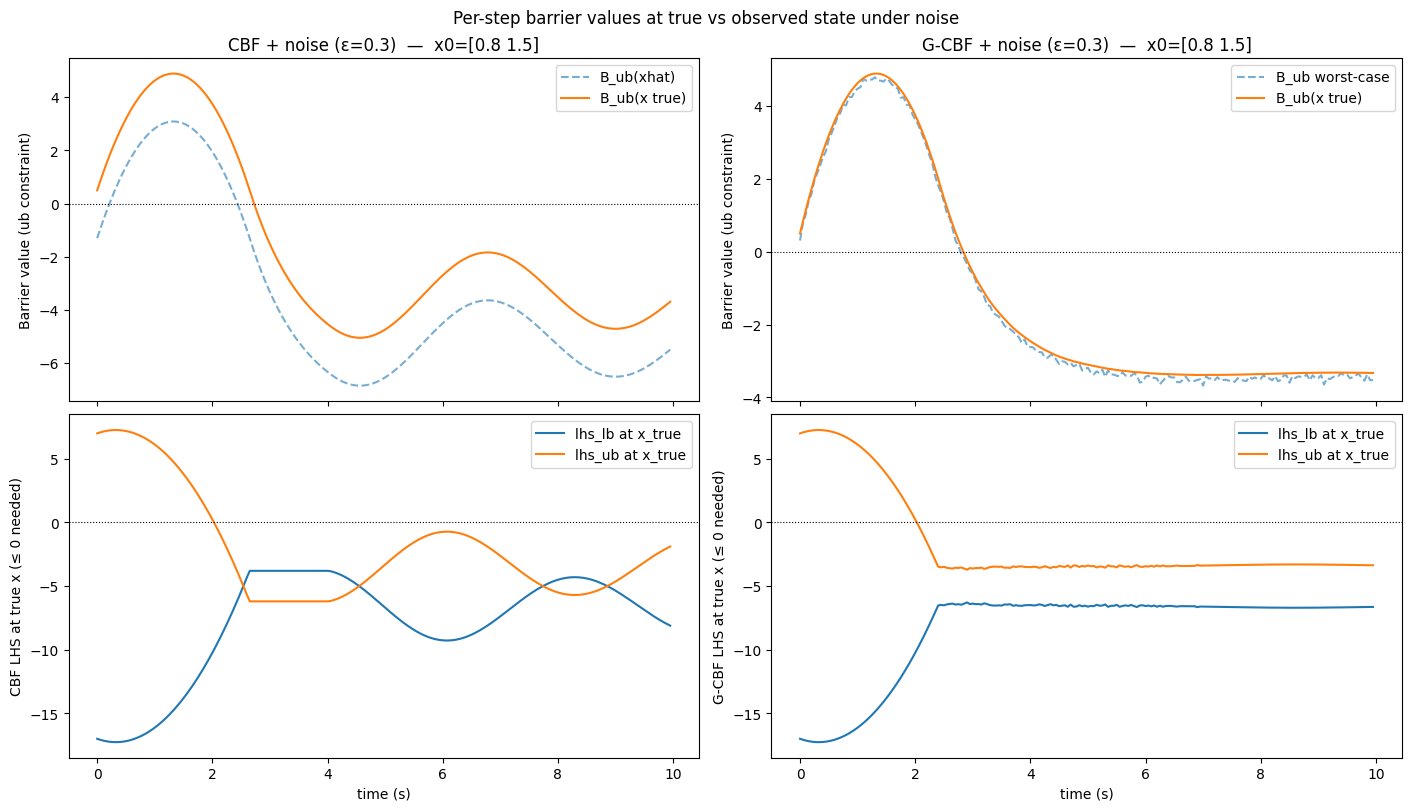

CBF:  steps where true-state LHS > 1e-4: 41/200
GCBF: steps where true-state LHS > 1e-4: 41/200


In [121]:
x0_diag2 = jnp.array([0.8, 1.5])

# Record per-step diagnostics for the perturbed case
@jax.jit
def cbf_ptb_step_diag(x, step_idx):
    ptb_key = jax.random.fold_in(PTB_KEY, step_idx)
    # ptb     = jax.random.uniform(ptb_key, shape=x.shape,
    #                              minval=-PTB_SCALE, maxval=PTB_SCALE)
    ptb     = -PTB_SCALE
    xhat    = x + ptb
    B_hat   = B_hocbf(xhat)                              # B at observed state
    B_true  = B_hocbf(x)                                 # B at true state
    Bx_hat  = jax.jacobian(B_hocbf)(xhat)
    u_opt, r, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub,
                                B_hat, Bx_hat, f(xhat), G(xhat), nom_pol(xhat))
    # CBF LHS evaluated at the TRUE state (what actually matters for safety)
    Bx_true = jax.jacobian(B_hocbf)(x)
    lhs_true = Bx_true @ f(x) + (Bx_true @ G(x) @ u_opt).ravel() + ALPHA_QP * B_true
    x_next  = x + DT * (f(x) + G(x) @ u_opt)
    return x_next, (B_hat, B_true, lhs_true, ptb)

@jax.jit
def gcbf_ptb_step_diag(x, step_idx):
    key              = jax.random.fold_in(PTB_KEY, step_idx)
    ptb_key, smp_key = jax.random.split(key)
    # ptb   = jax.random.uniform(ptb_key, shape=x.shape,
    #                            minval=-PTB_SCALE, maxval=PTB_SCALE)
    ptb   = -PTB_SCALE
    xhat  = x + ptb
    u_opt, r, h_V_wc, h_Lf_wc, h_LG_wc = gcbf_pol(xhat, smp_key,
                                                     epsilon=PTB_SCALE)
    B_true   = B_hocbf(x)
    Bx_true  = jax.jacobian(B_hocbf)(x)
    lhs_true = Bx_true @ f(x) + (Bx_true @ G(x) @ u_opt).ravel() + ALPHA_QP * B_true
    x_next   = x + DT * (f(x) + G(x) @ u_opt)
    return x_next, (h_V_wc, B_true, lhs_true, ptb)

_, (cbf_Bhat, cbf_Btrue, cbf_lhs_true, cbf_ptbs) = jax.lax.scan(
    cbf_ptb_step_diag, x0_diag2, jnp.arange(T)
)
_, (gc_Bwc, gc_Btrue, gc_lhs_true, gc_ptbs) = jax.lax.scan(
    gcbf_ptb_step_diag, x0_diag2, jnp.arange(T)
)

ts = jnp.arange(T) * DT
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, layout="constrained")

# CBF: B_hat vs B_true
axes[0, 0].plot(ts, cbf_Bhat[:, 1],  label='B_ub(xhat)', ls='--', alpha=0.6)
axes[0, 0].plot(ts, cbf_Btrue[:, 1], label='B_ub(x true)', lw=1.5)
axes[0, 0].axhline(0, color='k', lw=0.8, ls=':')
axes[0, 0].set_ylabel('Barrier value (ub constraint)')
axes[0, 0].set_title(f'CBF + noise (ε={PTB_SCALE})  —  x0={np.array(x0_diag2)}')
axes[0, 0].legend()

# G-CBF: B_wc vs B_true
axes[0, 1].plot(ts, gc_Bwc[:, 1],   label='B_ub worst-case', ls='--', alpha=0.6)
axes[0, 1].plot(ts, gc_Btrue[:, 1], label='B_ub(x true)', lw=1.5)
axes[0, 1].axhline(0, color='k', lw=0.8, ls=':')
axes[0, 1].set_ylabel('Barrier value (ub constraint)')
axes[0, 1].set_title(f'G-CBF + noise (ε={PTB_SCALE})  —  x0={np.array(x0_diag2)}')
axes[0, 1].legend()

# CBF: LHS at true state (positive = safety actually violated)
axes[1, 0].plot(ts, cbf_lhs_true[:, 0], label='lhs_lb at x_true')
axes[1, 0].plot(ts, cbf_lhs_true[:, 1], label='lhs_ub at x_true')
axes[1, 0].axhline(0, color='k', lw=0.8, ls=':')
axes[1, 0].set_ylabel('CBF LHS at true x (≤ 0 needed)')
axes[1, 0].set_xlabel('time (s)')
axes[1, 0].legend()

# G-CBF: LHS at true state
axes[1, 1].plot(ts, gc_lhs_true[:, 0], label='lhs_lb at x_true')
axes[1, 1].plot(ts, gc_lhs_true[:, 1], label='lhs_ub at x_true')
axes[1, 1].axhline(0, color='k', lw=0.8, ls=':')
axes[1, 1].set_ylabel('G-CBF LHS at true x (≤ 0 needed)')
axes[1, 1].set_xlabel('time (s)')
axes[1, 1].legend()

plt.suptitle("Per-step barrier values at true vs observed state under noise")
plt.show()

cbf_fail  = int(jnp.sum(jnp.any(cbf_lhs_true  > 1e-4, axis=-1)))
gcbf_fail = int(jnp.sum(jnp.any(gc_lhs_true   > 1e-4, axis=-1)))
print(f"CBF:  steps where true-state LHS > 1e-4: {cbf_fail}/{T}")
print(f"GCBF: steps where true-state LHS > 1e-4: {gcbf_fail}/{T}")

## B(x) at true state along perturbed trajectories

Even when the policy acts on $\hat{x}$, safety is determined by $B(x_{\text{true}})$.
This plots the true-state barrier value over time for both controllers under noise.

Perturbed rollouts (ptb_scale=0.3): cbf=9/10 violated, gcbf=4/10 violated


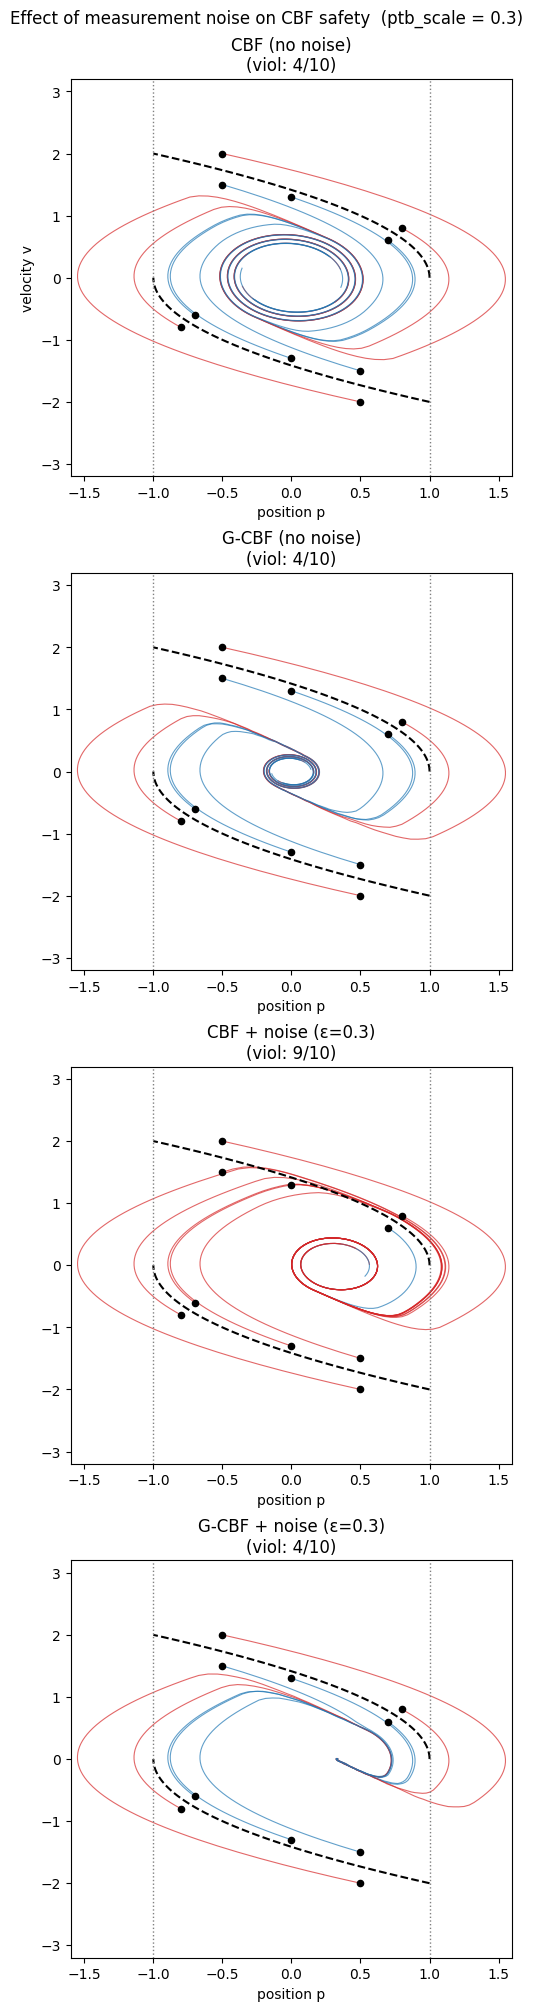

In [122]:
trajs_cbf_ptb  = jax.vmap(rollout_cbf_ptb)(x0s)
trajs_gcbf_ptb = jax.vmap(rollout_gcbf_ptb)(x0s)

n_cbf_ptb  = count_violations(trajs_cbf_ptb)
n_gcbf_ptb = count_violations(trajs_gcbf_ptb)
print(f"Perturbed rollouts (ptb_scale={PTB_SCALE}): "
      f"cbf={n_cbf_ptb}/{len(x0s)} violated, gcbf={n_gcbf_ptb}/{len(x0s)} violated")

fig, axes = plt.subplots(4, 1, figsize=(5, 20), sharey=True, layout="constrained")
panels = [
    (trajs_cbf,      f"CBF (no noise)"),
    (trajs_gcbf,     f"G-CBF (no noise)"),
    (trajs_cbf_ptb,  f"CBF + noise (ε={PTB_SCALE})"),
    (trajs_gcbf_ptb, f"G-CBF + noise (ε={PTB_SCALE})"),
]

for ax, (trajs, title) in zip(axes, panels):
    n_v = count_violations(trajs)
    for traj in np.array(trajs):
        violated = np.any(np.abs(traj[:, 0]) > PWALL + 1e-3)
        ax.plot(traj[:, 0], traj[:, 1],
                color="C3" if violated else "C0", lw=0.8, alpha=0.7)
        ax.scatter(traj[0, 0], traj[0, 1], s=20, color="k", zorder=5)
    ax.plot(ci_p_right, vs_pos, 'k--', lw=1.5)
    ax.plot(ci_p_left,  vs_neg, 'k--', lw=1.5)
    for xw in [-PWALL, PWALL]:
        ax.axvline(xw, color='gray', lw=1.0, ls=':')
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-3.2, 3.2)
    ax.set_xlabel("position p")
    ax.set_title(f"{title}\n(viol: {n_v}/{len(x0s)})")

axes[0].set_ylabel("velocity v")
plt.suptitle(f"Effect of measurement noise on CBF safety  (ptb_scale = {PTB_SCALE})")
plt.show()

---
## Optimization-based worst-case: alternatives to sampling

Three approaches to finding `(h_V_wc, h_Lf_V_wc, h_LG_V_wc)`:

| Method | Exact? | Cost | When to use |
|---|---|---|---|
| **Sampling** | No (stochastic) | O(N) evaluations | Any CBF; simple baseline |
| **Vertex enumeration** | Yes (affine CBF) | 2^nx evaluations | Linear/affine B(x) |
| **Projected gradient ascent** | No (local optima) | n_restarts × n_steps evals | Any differentiable CBF |

For this HOCBF, $B(x)$ is affine in $x$ so the maximum over a box is always attained at a
corner — **vertex enumeration is exact with just 4 evaluations** (vs 200 samples).
For a neural-network CBF, gradient ascent is the practical option since B is nonlinear.
Both are fully JIT-able.

In [123]:
import itertools

# ── Vertex enumeration ────────────────────────────────────────────────────────
# All 2^nx corners of the unit box, computed once at Python time (static).
_NX    = 2
_SIGNS = jnp.array(list(itertools.product(*[[-1.0, 1.0]] * _NX)))  # (4, 2)

@jax.jit
def gcbf_pol_vertices(xhat, epsilon=PTB_SCALE, alpha_qp=ALPHA_QP):
    """
    Exact worst-case G-CBF for affine B(x): evaluates all 2^nx box corners.
    For the HOCBF, B, Lf_B, LG_B are all linear/constant in x, so this is
    the global optimum — no sampling or gradient required.
    """
    corners = xhat[None] + epsilon * _SIGNS       # (2^nx, nx)
    h_V_s, h_LfV_s, h_LGV_s = jax.vmap(_gcbf_ingredients)(corners)

    nh = h_V_s.shape[1]
    ci = jnp.arange(nh)
    wc_hV  = jnp.argmax(h_V_s,   axis=0)
    wc_LfV = jnp.argmax(h_LfV_s, axis=0)
    wc_LGV = jnp.argmin(jnp.linalg.norm(h_LGV_s, axis=-1), axis=0)

    h_V_wc  = h_V_s [wc_hV,  ci]
    h_Lf_wc = h_LfV_s[wc_LfV, ci]
    h_LG_wc = h_LGV_s[wc_LGV, ci, :]

    u_opt, r, _ = gcbf_qp(alpha_qp, u_lb, u_ub,
                           h_V_wc, h_Lf_wc, h_LG_wc,
                           nom_pol(xhat), relax_eps2=0.1)
    return u_opt, r, h_V_wc, h_Lf_wc, h_LG_wc


# ── Projected gradient ascent ─────────────────────────────────────────────────
def proj_grad_max(scalar_fn, xhat, epsilon, n_restarts, n_steps, lr, key):
    """
    Maximize scalar_fn(x) over the box [xhat-ε, xhat+ε] via projected gradient
    ascent run in parallel from n_restarts starting points.
    Returns (max_value, argmax_x).
    """
    x0s = xhat[None] + jax.random.uniform(
        key, (n_restarts, xhat.shape[0]), minval=-epsilon, maxval=epsilon
    )
    def run_one(x0):
        def step(x, _):
            g = jax.grad(scalar_fn)(x)
            return jnp.clip(x + lr * g, xhat - epsilon, xhat + epsilon), None
        x_star, _ = jax.lax.scan(step, x0, None, length=n_steps)
        return scalar_fn(x_star), x_star
    vals, xs = jax.vmap(run_one)(x0s)
    best = jnp.argmax(vals)
    return vals[best], xs[best]

_NH = 2   # number of constraints (fixed for this system)

@ft.partial(jax.jit, static_argnames=("n_restarts", "n_steps"))
def gcbf_pol_gradopt(xhat, rng_key, epsilon=PTB_SCALE, alpha_qp=ALPHA_QP,
                     n_restarts=1, n_steps=20, lr=0.05):
    """
    G-CBF worst-case via projected gradient ascent.
    Runs 3 × nh independent maximizations (one per term per constraint),
    each with n_restarts starting points in parallel.
    """
    # One key per optimization problem (3 per constraint: h_V, Lf_V, LG_V)
    keys = jax.random.split(rng_key, 3 * _NH)   # (3*nh, 2)

    def worst_h_V_i(i, key):
        _, x = proj_grad_max(lambda x: B_hocbf(x)[i],
                             xhat, epsilon, n_restarts, n_steps, lr, key)
        return _gcbf_ingredients(x)[0][i]

    def worst_Lf_V_i(i, key):
        _, x = proj_grad_max(lambda x: _gcbf_ingredients(x)[1][i],
                             xhat, epsilon, n_restarts, n_steps, lr, key)
        return _gcbf_ingredients(x)[1][i]

    def worst_LG_V_i(i, key):
        # Minimise ||LG_V|| = maximise its negative
        _, x = proj_grad_max(lambda x: -jnp.linalg.norm(_gcbf_ingredients(x)[2][i]),
                             xhat, epsilon, n_restarts, n_steps, lr, key)
        return _gcbf_ingredients(x)[2][i]

    ci = jnp.arange(_NH)
    h_V_wc  = jax.vmap(worst_h_V_i )(ci, keys[        : _NH  ])   # (nh,)
    h_Lf_wc = jax.vmap(worst_Lf_V_i)(ci, keys[  _NH   : 2*_NH])   # (nh,)
    h_LG_wc = jax.vmap(worst_LG_V_i)(ci, keys[2*_NH   :       ])   # (nh, nu)

    u_opt, r, _ = gcbf_qp(alpha_qp, u_lb, u_ub,
                           h_V_wc, h_Lf_wc, h_LG_wc,
                           nom_pol(xhat), relax_eps2=0.1)
    return u_opt, r, h_V_wc, h_Lf_wc, h_LG_wc

# Compile
print("Compiling optimisation-based methods...")
_x_dummy = jnp.array([0.5, 0.5])
_k_dummy = jax.random.PRNGKey(0)
gcbf_pol_vertices(_x_dummy)
gcbf_pol_gradopt(_x_dummy, _k_dummy)
print("Done.")

Compiling optimisation-based methods...
Done.


## Accuracy comparison: do all three methods find the same worst case?

In [124]:
x_cmp = jnp.array([0.7, 1.2])
key_cmp = jax.random.PRNGKey(99)

_, _, hV_smp, Lf_smp, LG_smp = gcbf_pol(x_cmp, key_cmp, epsilon=PTB_SCALE, n_samples=2000)
_, _, hV_vrt, Lf_vrt, LG_vrt = gcbf_pol_vertices(x_cmp, epsilon=PTB_SCALE)
_, _, hV_grd, Lf_grd, LG_grd = gcbf_pol_gradopt(x_cmp, key_cmp, epsilon=PTB_SCALE)

rows = [
    ("Sampling (N=2000)", hV_smp, Lf_smp, LG_smp),
    ("Vertices  (N=4)  ", hV_vrt, Lf_vrt, LG_vrt),
    ("Grad opt  (r=8)  ", hV_grd, Lf_grd, LG_grd),
]
print(f"{'Method':<22}  {'h_V_wc':>14}  {'Lf_V_wc':>14}  {'LG_V_wc':>14}")
print("-" * 70)
for name, hv, lf, lg in rows:
    print(f"  {name}  {np.array(hv).round(4)!s:>14}  {np.array(lf).round(4)!s:>14}  {np.array(lg).round(4)!s:>14}")

print()
print("Note: for the affine HOCBF, vertex enumeration is the exact optimum.")
print("Sampling should converge to it as N→∞; gradient ascent should match for linear objectives.")

Method                          h_V_wc         Lf_V_wc         LG_V_wc
----------------------------------------------------------------------
  Sampling (N=2000)  [-7.9164  1.4909]  [-4.5002  7.4965]  [[-1.]
 [ 1.]]
  Vertices  (N=4)       [-7.9  1.5]     [-4.5  7.5]  [[-1.]
 [ 1.]]
  Grad opt  (r=8)       [-7.9  1.5]     [-4.5  7.5]  [[-1.]
 [ 1.]]

Note: for the affine HOCBF, vertex enumeration is the exact optimum.
Sampling should converge to it as N→∞; gradient ascent should match for linear objectives.


## Speed comparison

In [125]:
import time

def bench(fn, *args, reps=50):
    fn(*args).block_until_ready()   # ensure compiled
    t0 = time.perf_counter()
    for _ in range(reps):
        fn(*args).block_until_ready()
    return (time.perf_counter() - t0) / reps * 1e3

def first_return(*args):
    return args[0]

# Wrap each method to return just u_opt (a single array) for timing
gcbf_smp_u   = jax.jit(lambda x, k: gcbf_pol(x, k, epsilon=PTB_SCALE, n_samples=200)[0])
gcbf_vrt_u   = jax.jit(lambda x:    gcbf_pol_vertices(x, epsilon=PTB_SCALE)[0])
gcbf_grd_u   = jax.jit(lambda x, k: gcbf_pol_gradopt(x, k, epsilon=PTB_SCALE)[0])

# Compile
_ = gcbf_smp_u(x_cmp, key_cmp)
_ = gcbf_vrt_u(x_cmp)
_ = gcbf_grd_u(x_cmp, key_cmp)

t_smp = bench(gcbf_smp_u, x_cmp, key_cmp)
t_vrt = bench(gcbf_vrt_u, x_cmp)
t_grd = bench(gcbf_grd_u, x_cmp, key_cmp)

print(f"Sampling  (N=200):          {t_smp:.3f} ms")
print(f"Vertices  (N=4, exact):     {t_vrt:.3f} ms")
print(f"Grad opt  (r=8, s=40):      {t_grd:.3f} ms")

Sampling  (N=200):          1.329 ms
Vertices  (N=4, exact):     1.288 ms
Grad opt  (r=8, s=40):      1.608 ms


## Phase portrait: do the three methods produce similar trajectories under noise?

Compiling perturbed rollouts with new methods...
Done.


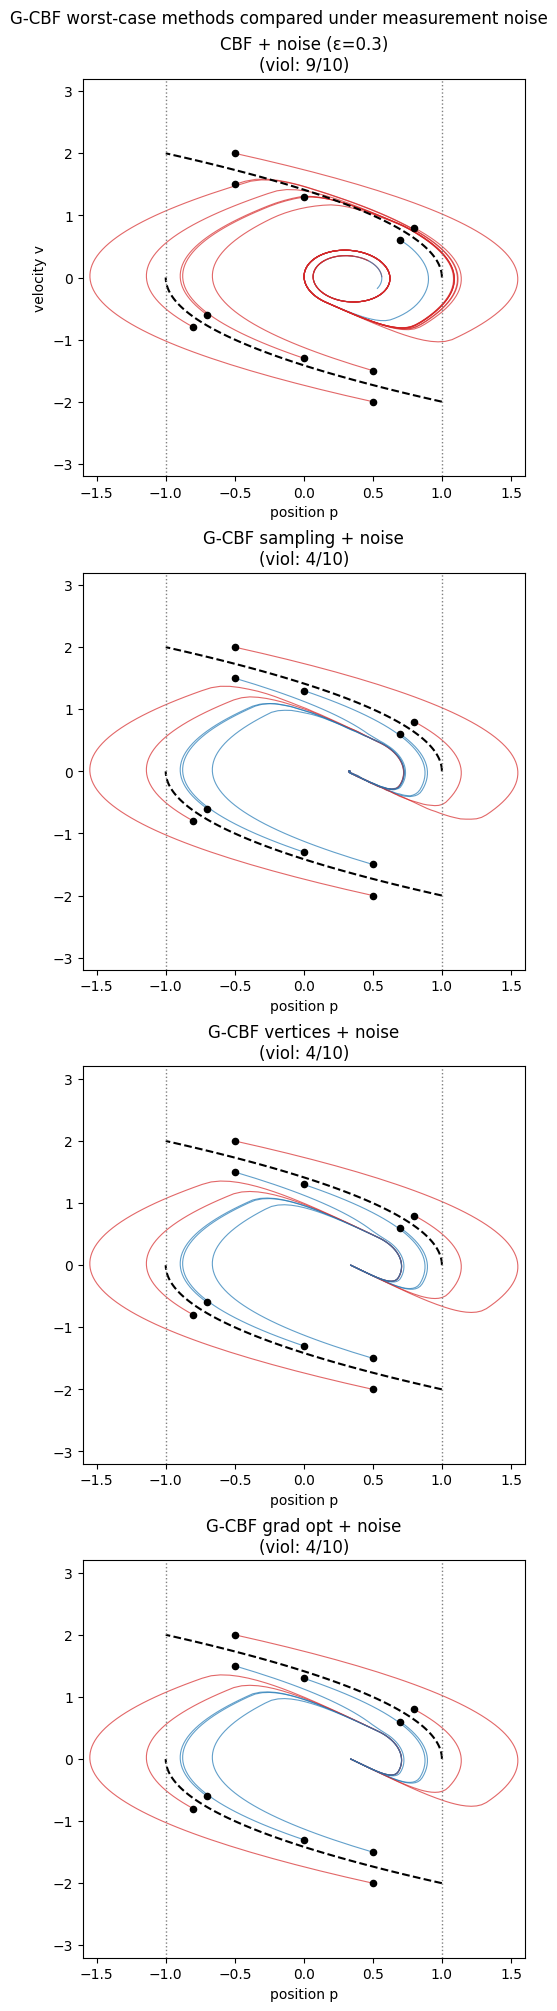

In [126]:
def make_gcbf_rollout_vertices(epsilon=PTB_SCALE, T=T, dt=DT, base_key=PTB_KEY):
    @jax.jit
    def rollout(x0):
        def step(x, step_idx):
            key = jax.random.fold_in(base_key, step_idx)
            ptb_key, _ = jax.random.split(key)
            # ptb    = jax.random.uniform(ptb_key, shape=x.shape,
            #                             minval=-epsilon, maxval=epsilon)
            ptb   = -epsilon
            xhat   = x + ptb
            u, _, _, _, _ = gcbf_pol_vertices(xhat, epsilon=epsilon)
            x_next = x + dt * (f(x) + G(x) @ u)
            return x_next, x
        _, xs = jax.lax.scan(step, x0, jnp.arange(T))
        return jnp.concatenate([x0[None], xs], axis=0)
    return rollout

def make_gcbf_rollout_gradopt(epsilon=PTB_SCALE, T=T, dt=DT, base_key=PTB_KEY):
    @jax.jit
    def rollout(x0):
        def step(x, step_idx):
            key = jax.random.fold_in(base_key, step_idx)
            ptb_key, smp_key = jax.random.split(key)
            # ptb    = jax.random.uniform(ptb_key, shape=x.shape,
            #                             minval=-epsilon, maxval=epsilon)
            ptb   = -epsilon
            xhat   = x + ptb
            u, _, _, _, _ = gcbf_pol_gradopt(xhat, smp_key, epsilon=epsilon)
            x_next = x + dt * (f(x) + G(x) @ u)
            return x_next, x
        _, xs = jax.lax.scan(step, x0, jnp.arange(T))
        return jnp.concatenate([x0[None], xs], axis=0)
    return rollout

rollout_gcbf_vrt = make_gcbf_rollout_vertices()
rollout_gcbf_grd = make_gcbf_rollout_gradopt()

print("Compiling perturbed rollouts with new methods...")
_ = rollout_gcbf_vrt(x_dummy)
_ = rollout_gcbf_grd(x_dummy)
print("Done.")

trajs_gcbf_vrt = jax.vmap(rollout_gcbf_vrt)(x0s)
trajs_gcbf_grd = jax.vmap(rollout_gcbf_grd)(x0s)

panels = [
    (trajs_cbf_ptb,   f"CBF + noise (ε={PTB_SCALE})"),
    (trajs_gcbf_ptb,  f"G-CBF sampling + noise"),
    (trajs_gcbf_vrt,  f"G-CBF vertices + noise"),
    (trajs_gcbf_grd,  f"G-CBF grad opt + noise"),
]

fig, axes = plt.subplots(4, 1, figsize=(5, 20), sharey=True, layout="constrained")
for ax, (trajs, title) in zip(axes, panels):
    n_v = count_violations(trajs)
    for traj in np.array(trajs):
        violated = np.any(np.abs(traj[:, 0]) > PWALL + 1e-3)
        ax.plot(traj[:, 0], traj[:, 1],
                color="C3" if violated else "C0", lw=0.8, alpha=0.7)
        ax.scatter(traj[0, 0], traj[0, 1], s=20, color="k", zorder=5)
    ax.plot(ci_p_right, vs_pos, 'k--', lw=1.5)
    ax.plot(ci_p_left,  vs_neg, 'k--', lw=1.5)
    for xw in [-PWALL, PWALL]:
        ax.axvline(xw, color="gray", lw=1.0, ls=":")
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-3.2, 3.2)
    ax.set_xlabel("position p")
    ax.set_title(f"{title}\n(viol: {n_v}/{len(x0s)})")
axes[0].set_ylabel("velocity v")
plt.suptitle("G-CBF worst-case methods compared under measurement noise")
plt.show()

---
## Learning $\phi$: a correction term for the nominal CBF condition

The G-CBF replaces the nominal CBF constraint with a worst-case version:
$$[L_f h_{\text{nom}} + \alpha h_{\text{nom}}] \;\longrightarrow\; [L_f h_{\text{wc}} + \alpha h_{\text{wc}}]$$

Instead of solving an optimisation at every timestep, we can **learn a scalar correction**
$\phi(\hat{x}) \geq 0$ such that:
$$L_f h(\hat{x}) + L_g h(\hat{x})\,u + \alpha h(\hat{x}) + \phi(\hat{x}) \approx L_f h_{\text{wc}} + L_g h_{\text{wc}}\,u + \alpha h_{\text{wc}}$$

We ignore the $L_g h$ difference for now (it is zero for this HOCBF since $B_x$ and $G$ are both constant).

In the CBF-QP, adding $\phi$ to the constraint is equivalent to tightening the effective barrier:
$$h_{\text{tight}} = h(\hat{x}) + \phi(\hat{x})/\alpha$$

**Note:** For this affine HOCBF, $\phi$ is *state-independent* (just $\alpha\varepsilon(2+\alpha)$),
so this is an easy sanity check.  For a neural-network CBF, $\phi(\hat{x})$ will be
genuinely state-dependent and the MLP will do real work.

In [127]:
import flax.linen as nn
import optax

# ── Ground-truth phi via vertex enumeration ───────────────────────────────────
@jax.jit
def _wc_h_Lf(xhat, epsilon=PTB_SCALE):
    """Worst-case (h_V_wc, Lf_V_wc) per constraint, via vertex enumeration."""
    corners = xhat[None] + epsilon * _SIGNS      # (2^nx, nx)
    h_V_s, h_LfV_s, _ = jax.vmap(_gcbf_ingredients)(corners)
    nh = h_V_s.shape[1]
    ci = jnp.arange(nh)
    return h_V_s[jnp.argmax(h_V_s, axis=0), ci], h_LfV_s[jnp.argmax(h_LfV_s, axis=0), ci]

@jax.jit
def phi_true_fn(xhat, epsilon=PTB_SCALE, alpha=ALPHA_QP):
    """
    phi[i] = (Lf_h_wc[i] + alpha * h_wc[i]) - (Lf_h_nom[i] + alpha * h_nom[i])

    This is the exact correction needed to make the nominal CBF condition as tight
    as the worst-case G-CBF condition (ignoring LG_h differences).
    """
    h_nom  = B_hocbf(xhat)
    Lf_nom = jax.jacobian(B_hocbf)(xhat) @ f(xhat)   # (nh,)
    h_wc, Lf_wc = _wc_h_Lf(xhat, epsilon)
    return (Lf_wc + alpha * h_wc) - (Lf_nom + alpha * h_nom)   # (nh,) >= 0

# Quick check: for affine HOCBF, phi should be the constant alpha*eps*(2+alpha)
x_check = jnp.array([0.3, -0.7])
phi_analytical = ALPHA_QP * PTB_SCALE * (2 + ALPHA_QP)
phi_computed   = phi_true_fn(x_check)
print(f"phi_true at {np.array(x_check)}:  {np.array(phi_computed).round(5)}")
print(f"Analytical  alpha*eps*(2+alpha) = {phi_analytical:.5f}")
print(f"(Should match since B(x) is affine in x)") 

phi_true at [ 0.3 -0.7]:  [3.3 3.3]
Analytical  alpha*eps*(2+alpha) = 0.90000
(Should match since B(x) is affine in x)


In [128]:
# ── Generate dataset ─────────────────────────────────────────────────────────
N_TRAIN, N_TEST = 4000, 1000

x_lo = jnp.array([-1.2, -2.5])
x_hi = jnp.array([ 1.2,  2.5])

rng_d = jax.random.PRNGKey(7)
rng_tr, rng_te = jax.random.split(rng_d)

xhat_train = x_lo + jax.random.uniform(rng_tr, (N_TRAIN, 2)) * (x_hi - x_lo)
xhat_test  = x_lo + jax.random.uniform(rng_te, (N_TEST,  2)) * (x_hi - x_lo)

phi_train = jax.vmap(phi_true_fn)(xhat_train)   # (N_TRAIN, nh)
phi_test  = jax.vmap(phi_true_fn)(xhat_test)    # (N_TEST,  nh)

print(f"phi stats — mean: {float(jnp.mean(phi_train)):.4f}, "
      f"std: {float(jnp.std(phi_train)):.6f}, "
      f"min: {float(jnp.min(phi_train)):.4f}, "
      f"max: {float(jnp.max(phi_train)):.4f}")
print("(Near-zero std confirms phi is state-independent for this HOCBF)")

phi stats — mean: 3.2994, std: 0.002578, min: 3.2941, max: 3.3039
(Near-zero std confirms phi is state-independent for this HOCBF)


In [129]:
# ── MLP definition ────────────────────────────────────────────────────────────
class PhiNet(nn.Module):
    """
    Predicts phi(xhat, epsilon): the correction to the nominal CBF condition.

    Inputs : xhat  (nx,)   — observed state
    Outputs: phi   (nh,)   — one correction per constraint
    phi >= 0 always (softplus output), since worst-case >= nominal by definition.
    """
    hidden_dims: tuple = (32, 32)
    n_constraints: int = _NH

    @nn.compact
    def __call__(self, xhat):
        x = xhat
        for h in self.hidden_dims:
            x = nn.Dense(h)(x)
            x = nn.tanh(x)
        # softplus enforces phi >= 0
        return nn.softplus(nn.Dense(self.n_constraints)(x))

phi_net   = PhiNet()
key_init  = jax.random.PRNGKey(0)
params    = phi_net.init(key_init, jnp.zeros(2))['params']
optimizer = optax.adam(3e-3)
opt_state = optimizer.init(params)

n_params = sum(p.size for p in jax.tree_util.tree_leaves(params))
print(f"PhiNet parameters: {n_params}")

PhiNet parameters: 1218


Epoch  50  train_loss=2.71e-04  val_mse=3.13e-04
Epoch 100  train_loss=1.27e-04  val_mse=9.10e-05
Epoch 150  train_loss=5.11e-05  val_mse=5.40e-05
Epoch 200  train_loss=3.31e-05  val_mse=3.89e-05


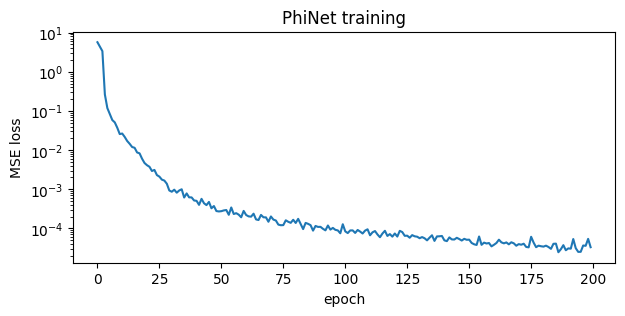

In [130]:
# ── Training loop ─────────────────────────────────────────────────────────────
BATCH_SIZE = 256
N_EPOCHS   = 200

@jax.jit
def train_step(params, opt_state, xhat_b, phi_b):
    def loss_fn(p):
        phi_pred = jax.vmap(lambda x: phi_net.apply({'params': p}, x))(xhat_b)
        return jnp.mean((phi_pred - phi_b) ** 2)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt = optimizer.update(grads, opt_state, params)
    return optax.apply_updates(params, updates), new_opt, loss

rng_ep = jax.random.PRNGKey(42)
train_losses = []

for epoch in range(N_EPOCHS):
    rng_ep, rng_shuf = jax.random.split(rng_ep)
    perm = jax.random.permutation(rng_shuf, N_TRAIN)
    epoch_loss = 0.0
    for b in range(0, N_TRAIN, BATCH_SIZE):
        idx = perm[b : b + BATCH_SIZE]
        params, opt_state, loss = train_step(params, opt_state,
                                             xhat_train[idx], phi_train[idx])
        epoch_loss = float(loss)
    train_losses.append(epoch_loss)
    if (epoch + 1) % 50 == 0:
        phi_pred_val = jax.vmap(lambda x: phi_net.apply({'params': params}, x))(xhat_test)
        val_mse = float(jnp.mean((phi_pred_val - phi_test) ** 2))
        print(f"Epoch {epoch+1:3d}  train_loss={epoch_loss:.2e}  val_mse={val_mse:.2e}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(train_losses)
ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss"); ax.set_title("PhiNet training")
plt.show()

Grid MSE: 3.92e-05   Max abs error: 0.0267
Points where phi_pred < phi_true (unsafe underestimate): 1922/2500


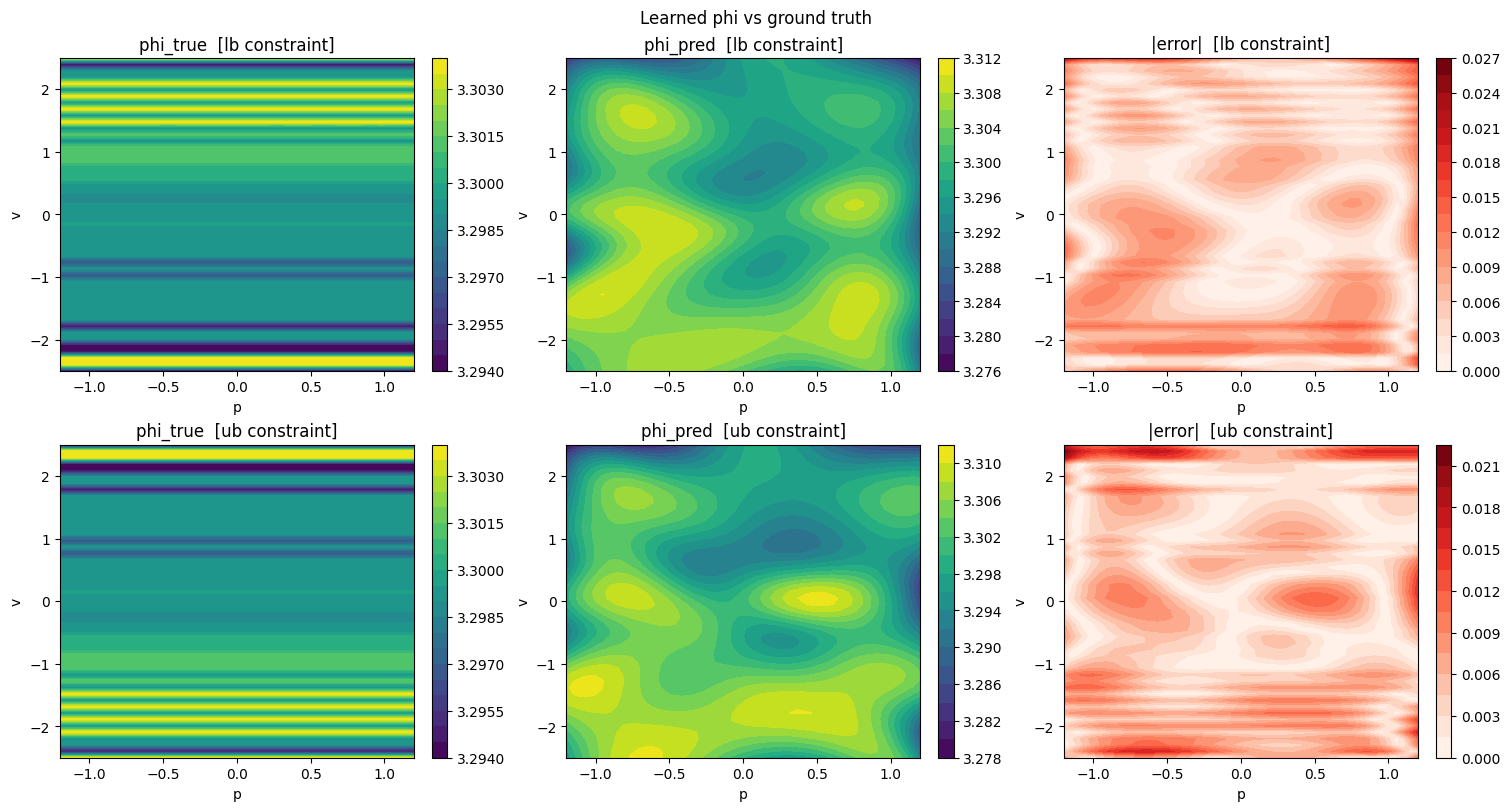

In [131]:
# ── Evaluation: learned phi vs true phi on a 2-D grid ─────────────────────────
n_pts = 50
ps = np.linspace(-1.2, 1.2, n_pts)
vs = np.linspace(-2.5, 2.5, n_pts)
PP, VV = np.meshgrid(ps, vs)
grid_x = jnp.array(np.stack([PP.ravel(), VV.ravel()], axis=1))   # (n^2, 2)

phi_grid_true = jax.vmap(phi_true_fn)(grid_x)                              # (n^2, nh)
phi_grid_pred = jax.vmap(lambda x: phi_net.apply({'params': params}, x))(grid_x)

err_grid = jnp.abs(phi_grid_pred - phi_grid_true)   # (n^2, nh)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), layout="constrained")
labels = ['lb constraint', 'ub constraint']

for ci in range(_NH):
    # True phi
    im0 = axes[ci, 0].contourf(PP, VV, np.array(phi_grid_true[:, ci]).reshape(n_pts, n_pts),
                                 levels=20, cmap='viridis')
    axes[ci, 0].set_title(f'phi_true  [{labels[ci]}]')
    fig.colorbar(im0, ax=axes[ci, 0])

    # Predicted phi
    im1 = axes[ci, 1].contourf(PP, VV, np.array(phi_grid_pred[:, ci]).reshape(n_pts, n_pts),
                                 levels=20, cmap='viridis')
    axes[ci, 1].set_title(f'phi_pred  [{labels[ci]}]')
    fig.colorbar(im1, ax=axes[ci, 1])

    # Error
    im2 = axes[ci, 2].contourf(PP, VV, np.array(err_grid[:, ci]).reshape(n_pts, n_pts),
                                 levels=20, cmap='Reds')
    axes[ci, 2].set_title(f'|error|  [{labels[ci]}]')
    fig.colorbar(im2, ax=axes[ci, 2])

for ax in axes.ravel():
    ax.set_xlabel('p'); ax.set_ylabel('v')

test_mse   = float(jnp.mean((phi_grid_pred - phi_grid_true) ** 2))
max_err    = float(jnp.max(err_grid))
under_est  = int(jnp.sum(phi_grid_pred < phi_grid_true - 1e-4))
print(f"Grid MSE: {test_mse:.2e}   Max abs error: {max_err:.4f}")
print(f"Points where phi_pred < phi_true (unsafe underestimate): {under_est}/{len(grid_x)}")
plt.suptitle("Learned phi vs ground truth")
plt.show()

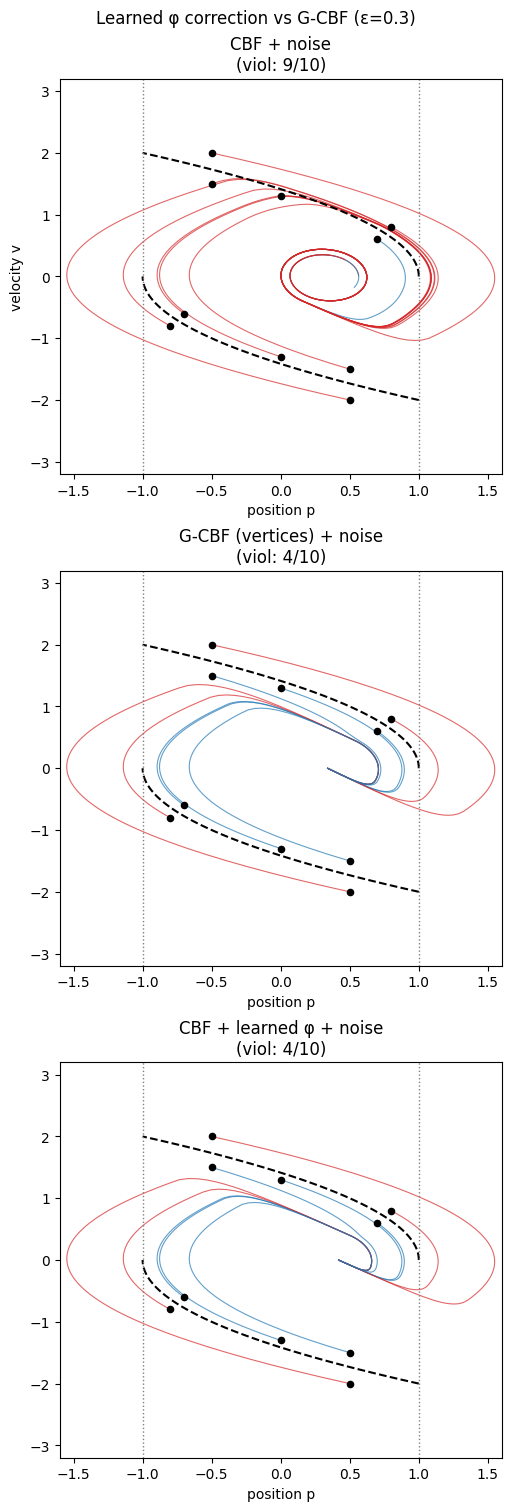

In [134]:
# ── CBF-QP with learned phi ───────────────────────────────────────────────────
_params_frozen = params   # snapshot for use inside jit

@jax.jit
def cbf_pol_phi(x, alpha=ALPHA_QP):
    """
    Standard CBF-QP tightened by the learned phi correction.

    Adding phi/alpha to h_V shifts the effective barrier inward so the QP enforces:
      Lf_h(xhat) + Lg_h(xhat)*u + alpha*(h + phi/alpha) <= 0
    which is equivalent to:
      Lf_h(xhat) + Lg_h(xhat)*u + alpha*h + phi         <= 0
    """
    h_V    = B_hocbf(x)
    hx_Vx  = jax.jacobian(B_hocbf)(x)
    phi    = phi_net.apply({'params': _params_frozen}, x)   # (nh,)
    h_tight = h_V + phi / alpha
    u_opt, r, _ = min_norm_cbf(alpha, u_lb, u_ub, h_tight, hx_Vx, f(x), G(x), nom_pol(x))
    return u_opt

# Perturbed rollout with phi-corrected CBF
def make_perturbed_phi_rollout(T=T, dt=DT, base_key=PTB_KEY):
    @jax.jit
    def rollout(x0):
        def step(x, step_idx):
            ptb_key = jax.random.fold_in(base_key, step_idx)
            # ptb     = jax.random.uniform(ptb_key, shape=x.shape,
            #                              minval=-PTB_SCALE, maxval=PTB_SCALE)
            ptb     = -PTB_SCALE
            xhat    = x + ptb
            u       = cbf_pol_phi(xhat)
            x_next  = x + dt * (f(x) + G(x) @ u)
            return x_next, x
        _, xs = jax.lax.scan(step, x0, jnp.arange(T))
        return jnp.concatenate([x0[None], xs], axis=0)
    return rollout

rollout_phi_ptb = make_perturbed_phi_rollout()
_ = rollout_phi_ptb(x_dummy)   # compile

trajs_phi_ptb = jax.vmap(rollout_phi_ptb)(x0s)

panels = [
    (trajs_cbf_ptb,   f"CBF + noise"),
    (trajs_gcbf_vrt,  f"G-CBF (vertices) + noise"),
    (trajs_phi_ptb,   f"CBF + learned φ + noise"),
]

fig, axes = plt.subplots(3, 1, figsize=(5, 15), sharey=True, layout="constrained")
for ax, (trajs, title) in zip(axes, panels):
    n_v = count_violations(trajs)
    for traj in np.array(trajs):
        violated = np.any(np.abs(traj[:, 0]) > PWALL + 1e-3)
        ax.plot(traj[:, 0], traj[:, 1],
                color="C3" if violated else "C0", lw=0.8, alpha=0.7)
        ax.scatter(traj[0, 0], traj[0, 1], s=20, color="k", zorder=5)
    ax.plot(ci_p_right, vs_pos, 'k--', lw=1.5)
    ax.plot(ci_p_left,  vs_neg, 'k--', lw=1.5)
    for xw in [-PWALL, PWALL]:
        ax.axvline(xw, color="gray", lw=1.0, ls=":")
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-3.2, 3.2)
    ax.set_xlabel("position p")
    ax.set_title(f"{title}\n(viol: {n_v}/{len(x0s)})")
axes[0].set_ylabel("velocity v")
plt.suptitle(f"Learned φ correction vs G-CBF (ε={PTB_SCALE})")
plt.show()